### PINN Weighting Schemes
#### Test of Methods on reduced dataset & epochs

In [8]:
%matplotlib inline
import matplotlib.pyplot as plt

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os, glob

def load_clean_log(scheme):
    model_dir = cfg.dirs.model_dir

    # Find any training_log_<scheme>.csv inside model subfolders
    files = glob.glob(os.path.join(model_dir, "**", f"training_log_{scheme}.csv"), recursive=True)

    if not files:
        print("No log file found for scheme:", scheme)
        return None

    # Use newest log
    log_file = max(files, key=os.path.getmtime)
    print("Using log:", log_file)

    # Load CSV
    df = pd.read_csv(log_file, comment="#", on_bad_lines="skip")

    # Remove repeated-header rows
    df = df[df["epoch"].astype(str).str.isnumeric()]

    # Convert epoch to int
    df["epoch"] = df["epoch"].astype(int)

    # Remove duplicated epochs (keep last)
    df = df.drop_duplicates(subset="epoch", keep="last")

    df = df.sort_values("epoch").reset_index(drop=True)

    return df

def show_log(df, n=10):
    if df is None:
        return
    print("\nFirst rows of log:")
    display(df.head(n))

def plot_losses(df, scheme):
    if df is None:
        return

    COLORS = {
        "train_total": "black",
        "train_data": "blue",
        "train_dt": "orange",
        "train_pinn": "green",
        "train_pinn_ic": "red",
    }

    plt.figure(figsize=(10,6))

    for key, color in COLORS.items():
        if key in df.columns:
            plt.plot(df["epoch"], df[key], label=key, color=color)

    plt.yscale("log")
    plt.title(f"Training Loss Curves – {scheme}", fontsize=16)
    plt.xlabel("Epoch")
    plt.ylabel("Loss (log scale)")
    plt.grid(True, which="both", ls="--", alpha=0.5)
    plt.legend()
    plt.tight_layout()
    plt.show()

def plot_weights(df, scheme):
    if df is None:
        return

    COLORS = {
        "weight_data": "blue",
        "weight_dt": "orange",
        "weight_pinn": "green",
        "weight_pinn_ic": "red",
    }

    plt.figure(figsize=(10,6))

    for key, color in COLORS.items():
        if key in df.columns:
            plt.plot(df["epoch"], df[key], label=key.replace("weight_", ""), color=color, linewidth=2)

    plt.title(f"Weight Evolution – {scheme}", fontsize=16)
    plt.xlabel("Epoch")
    plt.ylabel("Weight value")
    plt.yscale("log")
    plt.grid(True, ls="--", alpha=0.5)
    plt.legend()
    plt.tight_layout()
    plt.show()

In [3]:
# PINN Weighting Schemes 

import torch, copy, os
from omegaconf import OmegaConf
from src.nn.nn_dataset import DataSampler
from src.ode.sm_models_d import SynchronousMachineModels
from src.nn.nn_actions import NeuralNetworkActions

def detect_device():
    if torch.backends.mps.is_available():
        return torch.device("mps")
    elif torch.cuda.is_available():
        return torch.device("cuda")
    else:
        return torch.device("cpu")

device = detect_device()
print(f"Using device: {device}")
torch.autograd.set_detect_anomaly(False)

cfg = OmegaConf.load("src/conf/setup_dataset_nn.yaml")

cfg.nn.type = "DynamicNN"
cfg.nn.lr = 2e-3
cfg.nn.optimizer = "Adam"      # LBFGS causes autograd headaches during debug
cfg.nn.num_epochs = 300         # short debug run
cfg.nn.early_stopping = False

cfg.nn.weighting.update_weights_freq = 5

# Reduce data size to run faster
cfg.dataset.perc_of_data_points = 0.07
cfg.dataset.perc_of_col_points = 0.07

dataset_path = "data/SM_AVR_GOV/dataset_set5_mixed.pkl"
assert os.path.exists(dataset_path), "Dataset missing!"

def train_weighting_scheme(cfg, dataset_path, scheme_name, epochs):

    print(f"\n{'='*70}\nTRAINING SCHEME: {scheme_name}\n{'='*70}")

    cfg_local = copy.deepcopy(cfg)
    cfg_local.nn.weighting.update_weight_method = scheme_name
    cfg_local.nn.num_epochs = epochs

    # Create dataset + model
    ds = DataSampler(cfg_local, dataset_path=dataset_path)
    modelling_full = SynchronousMachineModels(cfg_local)
    network = NeuralNetworkActions(cfg_local, modelling_full, data_loader=ds)

    # Train (no wandb)
    network.pinn_train2(
        num_of_skip_data_points=1,
        num_of_skip_col_points=1,
        num_of_skip_val_points=1,
        wandb_run=None,
    )

    # Print summary
    print(f"\n {scheme_name} FINISHED.")
    print(f"   Final total loss: {network.loss_total.item():.4e}")
    print(f"   Data loss: {network.loss_data.item():.4e}")
    print(f"   dt loss: {network.loss_dt.item():.4e}")
    print(f"   PINN loss: {network.loss_pinn.item():.4e}")
    print(f"   IC loss: {network.loss_pinn_ic.item():.4e}")
    print(f"   Final weights:", network.weighting_scheme.weights.detach().cpu().numpy())
    print("\n")
    return network

Using device: cpu


### Static

In [24]:
train_weighting_scheme(cfg, dataset_path, "Static", epochs=300)


TRAINING SCHEME: Static
SM_AVR_GOV data
Loading data from: data/SM_AVR_GOV/dataset_set5_mixed.pkl
Number of training samples:  80000 Number of validation samples:  10000 Number of testing samples:  10000
Number of different initial conditions for collocation points:  100
['theta', 'omega', 'E_d_dash', 'E_q_dash', 'R_F', 'V_r', 'E_fd', 'P_sv', 'P_m'] Variables
[[-2, 2], [-1, 1], [0], [1], [1], [1.105], [1.08], [0.7048], [0.7048]] Set of values for init conditions
[10, 10, 1, 1, 1, 1, 1, 1, 1] Iterations per value
Selected deep learning model:  DynamicNN
Number of labeled training data: 5600 Number of collocation points: 7000 Number of collocation points (IC): 100 Number of validation data: 10000
Weights initialized as:  [1, 0.001, 0.0001, 0.001]  are updated with scheme:  Static 
Logging training to model/data_dt_pinn_ic/training_log_Static.csv
getting in training
Updating weights at epoch 5
Epoch 5 – Current weights: [1.e+00 1.e-03 1.e-04 1.e-03]
Updating weights at epoch 10
Epoch 10 

Using log: model/data_dt_pinn_ic/training_log_Static.csv

First rows of log:


,epoch,train_total,train_data,train_dt,train_pinn,train_pinn_ic,val_total,val_data,val_dt,weight_data,weight_dt,weight_pinn,weight_pinn_ic,elapsed_s
0,50,0.329895,0.265171,62.257614,4.127222,2.054438,61.453938,0.261101,61.192837,1.0,0.001,0.0001,0.001,22.941917
1,100,0.230324,0.164424,62.398323,3.242600,3.177209,61.499592,0.162189,61.337402,1.0,0.001,0.0001,0.001,46.124043
2,150,0.210195,0.145803,60.879700,4.248095,3.087269,59.863417,0.143542,59.719875,1.0,0.001,0.0001,0.001,69.120734
3,200,0.151414,0.096390,52.028976,6.916723,2.303891,50.545945,0.092618,50.453327,1.0,0.001,0.0001,0.001,92.491978
4,250,0.039663,0.017009,21.831285,3.744694,0.447606,20.541504,0.015344,20.526159,1.0,0.001,0.0001,0.001,115.035460
5,300,0.020829,0.007516,12.882349,2.911948,0.138562,11.878130,0.007599,11.870531,1.0,0.001,0.0001,0.001,137.804310


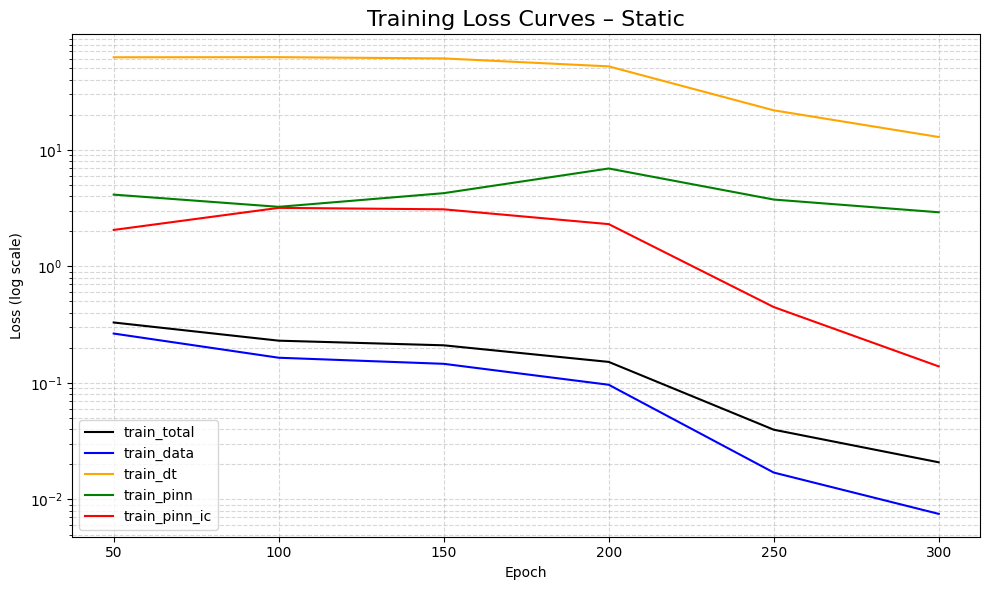

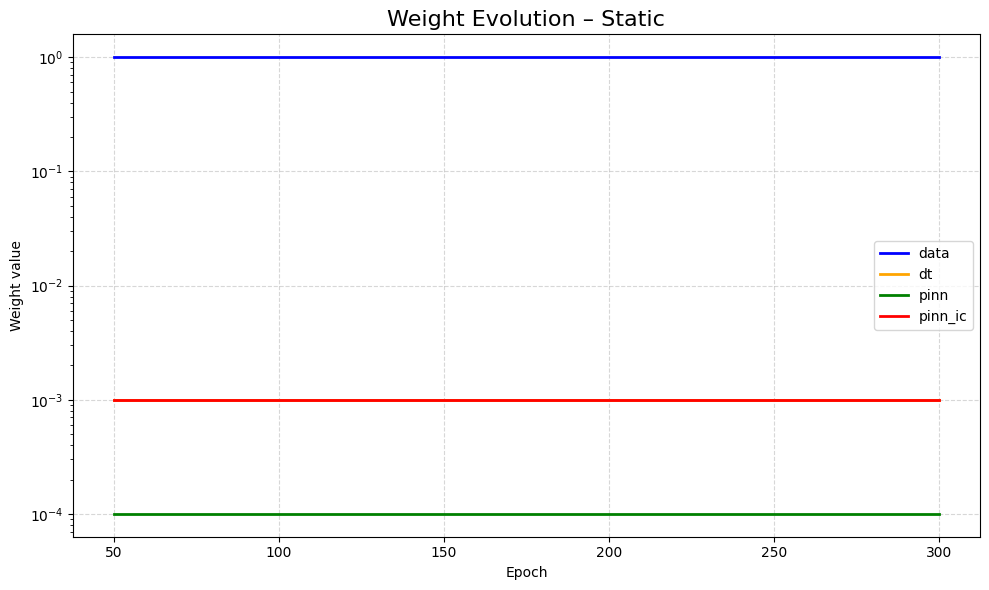

In [37]:
log = load_clean_log("Static")

show_log(log)

plot_losses(log, "Static")
plot_weights(log, "Static")

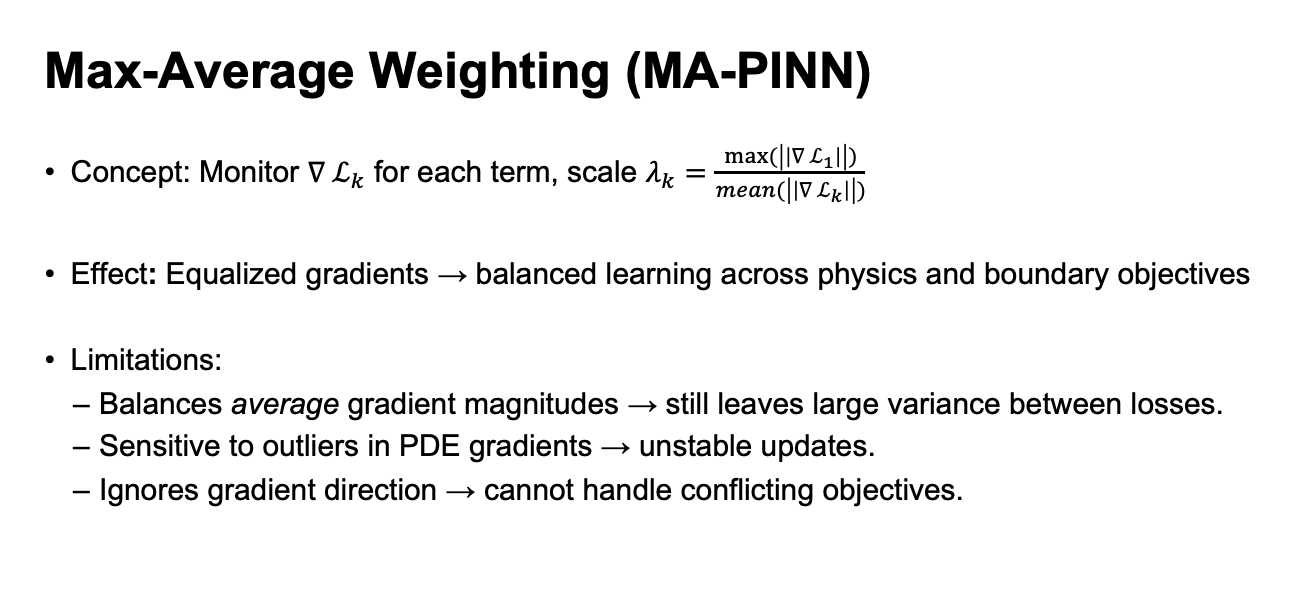

In [26]:
train_weighting_scheme(cfg, dataset_path, "Gradient", epochs=300)


TRAINING SCHEME: Gradient
SM_AVR_GOV data
Loading data from: data/SM_AVR_GOV/dataset_set5_mixed.pkl
Number of training samples:  80000 Number of validation samples:  10000 Number of testing samples:  10000
Number of different initial conditions for collocation points:  100
['theta', 'omega', 'E_d_dash', 'E_q_dash', 'R_F', 'V_r', 'E_fd', 'P_sv', 'P_m'] Variables
[[-2, 2], [-1, 1], [0], [1], [1], [1.105], [1.08], [0.7048], [0.7048]] Set of values for init conditions
[10, 10, 1, 1, 1, 1, 1, 1, 1] Iterations per value
Selected deep learning model:  DynamicNN
Number of labeled training data: 5600 Number of collocation points: 7000 Number of collocation points (IC): 100 Number of validation data: 10000
Weights initialized as:  [1, 0.001, 0.0001, 0.001]  are updated with scheme:  Gradient every 5 epochs
Logging training to model/data_dt_pinn_ic/training_log_Gradient.csv
getting in training
Updating weights at epoch 5

[Epoch 4] Updating weights (Gradient)
  → Updated weights: [0.2531, 0.5762

Using log: model/data_dt_pinn_ic/training_log_Gradient.csv

First rows of log:


,epoch,train_total,train_data,train_dt,train_pinn,train_pinn_ic,val_total,val_data,val_dt,weight_data,weight_dt,weight_pinn,weight_pinn_ic,elapsed_s
0,50,1.650629,0.577040,37.271217,5.437256,0.112963,34.616715,0.597298,34.019417,0.476213,0.032253,0.005518,0.486017,24.566138
1,100,0.320116,0.179887,18.548052,4.297628,0.087330,17.895761,0.172928,17.722834,0.859217,0.007522,0.001490,0.131771,50.030991
2,150,0.101151,0.029469,9.713612,1.053239,0.056623,9.044264,0.026352,9.017912,0.967621,0.005546,0.002457,0.024376,75.841348
3,200,0.038973,0.020531,8.567186,0.417221,0.052444,8.051057,0.018238,8.032819,0.972929,0.001916,0.003443,0.021712,101.584190
4,250,0.023496,0.016308,8.276753,0.348968,0.050825,7.791690,0.014364,7.777325,0.980674,0.000776,0.001218,0.017333,127.615146
5,300,0.022905,0.013164,8.084199,0.314835,0.052809,7.586689,0.011605,7.575084,0.976425,0.001067,0.002137,0.020371,153.579443
6,3200,0.000123,0.000015,0.001583,0.002141,0.000018,0.001625,0.000015,0.001610,0.900760,0.029588,0.004378,0.065274,4336.868479
7,3250,0.000123,0.000015,0.001583,0.002141,0.000018,0.001625,0.000015,0.001610,0.900760,0.029588,0.004378,0.065274,4382.058399
8,3300,0.000123,0.000015,0.001583,0.002141,0.000018,0.001625,0.000015,0.001610,0.900760,0.029588,0.004378,0.065274,4427.190575
9,3350,0.000123,0.000015,0.001583,0.002141,0.000018,0.001625,0.000015,0.001610,0.900760,0.029588,0.004378,0.065274,4472.582280


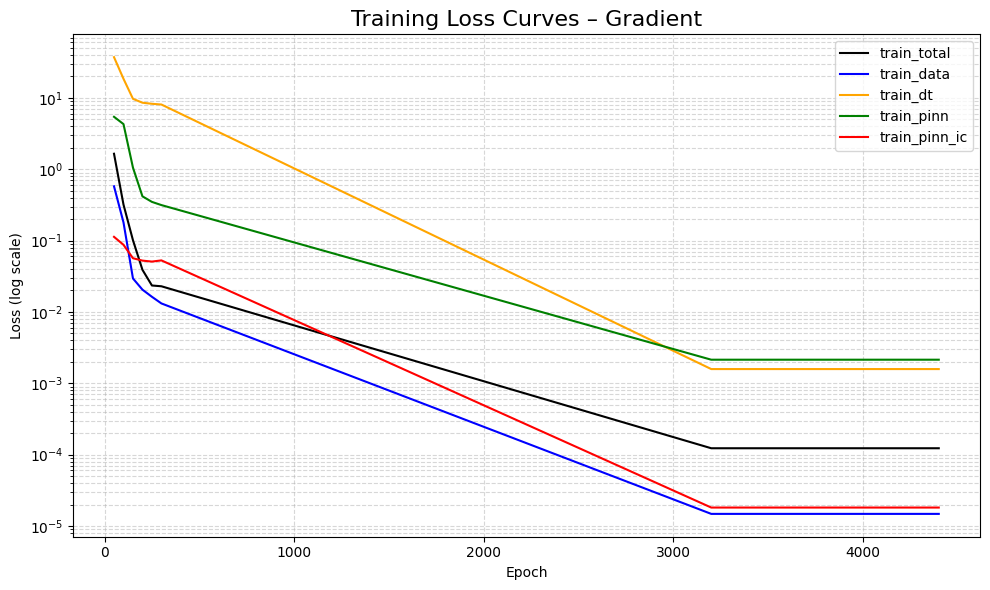

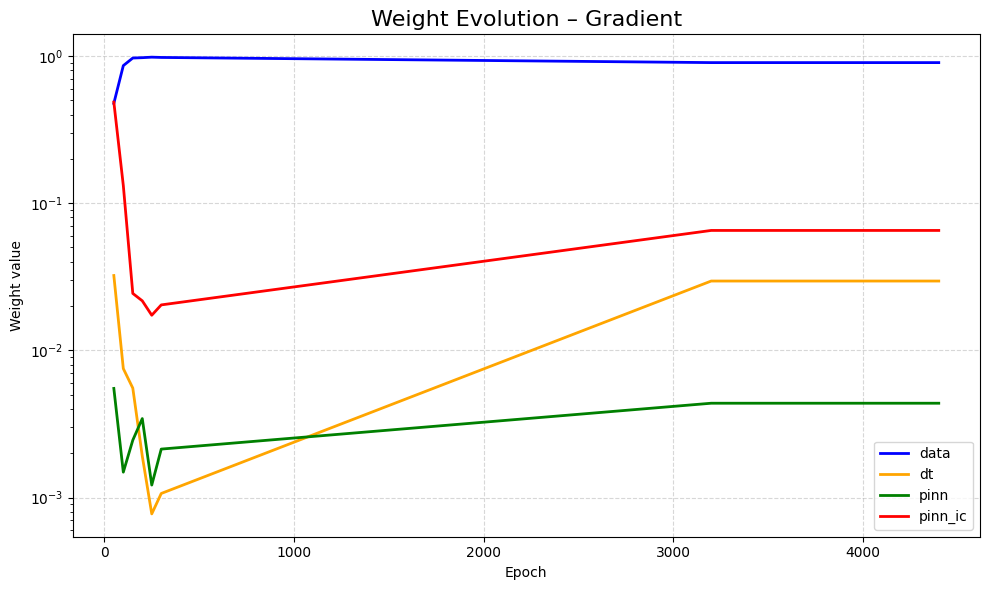

In [50]:
log = load_clean_log("Gradient")

show_log(log)

plot_losses(log, "Gradient")
plot_weights(log, "Gradient")

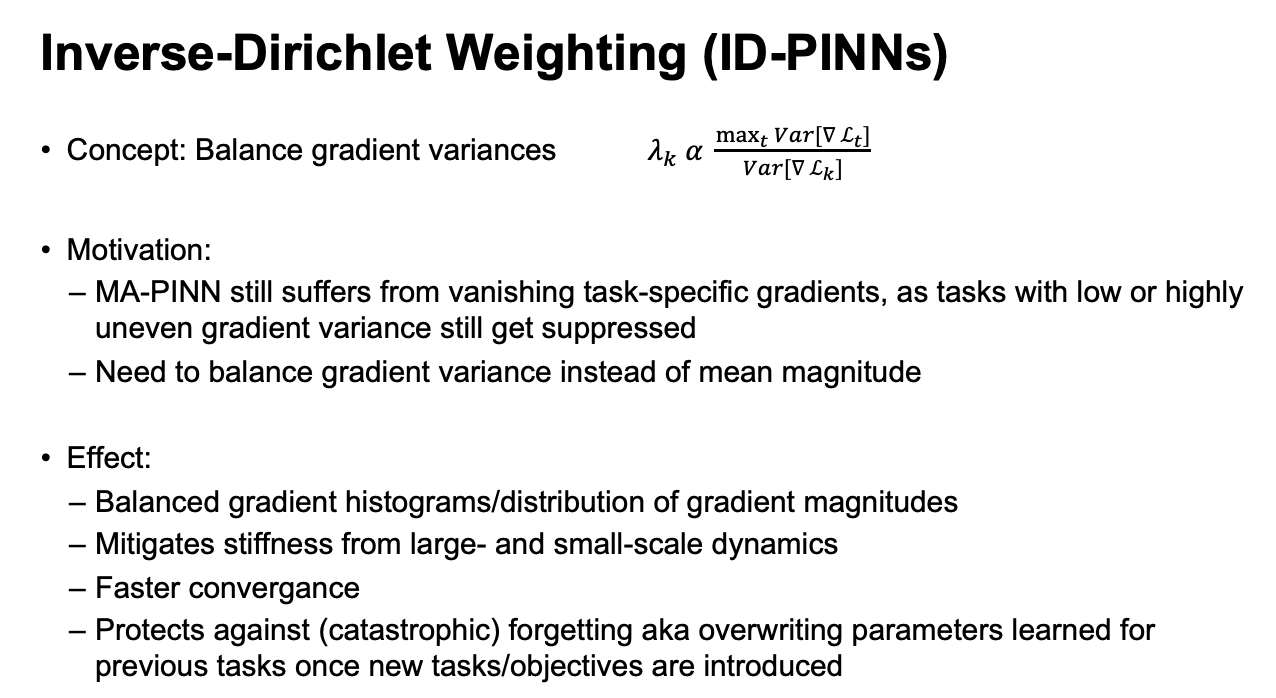

In [27]:
train_weighting_scheme(cfg, dataset_path, "ID", epochs=300)


TRAINING SCHEME: ID
SM_AVR_GOV data
Loading data from: data/SM_AVR_GOV/dataset_set5_mixed.pkl
Number of training samples:  80000 Number of validation samples:  10000 Number of testing samples:  10000
Number of different initial conditions for collocation points:  100
['theta', 'omega', 'E_d_dash', 'E_q_dash', 'R_F', 'V_r', 'E_fd', 'P_sv', 'P_m'] Variables
[[-2, 2], [-1, 1], [0], [1], [1], [1.105], [1.08], [0.7048], [0.7048]] Set of values for init conditions
[10, 10, 1, 1, 1, 1, 1, 1, 1] Iterations per value
Selected deep learning model:  DynamicNN
Number of labeled training data: 5600 Number of collocation points: 7000 Number of collocation points (IC): 100 Number of validation data: 10000
Weights initialized as:  [1, 0.001, 0.0001, 0.001]  are updated with scheme:  ID every 5 epochs
Logging training to model/data_dt_pinn_ic/training_log_ID.csv
getting in training
Updating weights at epoch 5

[Epoch 4] Updating weights (ID)
  → Updated weights: [0.1509, 0.781, 0.0, 0.0682]
Epoch 5 – 

Using log: model/data_dt_pinn_ic/training_log_ID.csv

First rows of log:


,epoch,train_total,train_data,train_dt,train_pinn,train_pinn_ic,val_total,val_data,val_dt,weight_data,weight_dt,weight_pinn,weight_pinn_ic,elapsed_s
0,50,0.450890,0.313437,61.213947,15.188250,1.506699,60.488232,0.310666,60.177567,0.994326,3.884089e-03,9.561340e-07,0.001789,26.629181
1,100,0.193630,0.183029,62.218636,20.094198,2.748750,61.311590,0.178759,61.132832,0.999701,8.319965e-05,6.728806e-09,0.000215,52.929963
2,150,0.143286,0.141739,60.004780,16.305998,2.954464,58.939074,0.138919,58.800156,0.999913,2.274667e-05,2.164993e-09,0.000064,79.509018
3,200,0.081244,0.080656,48.109951,20.316168,1.930956,46.578343,0.076924,46.501419,0.999940,6.233313e-06,7.864361e-09,0.000054,106.496387
4,250,0.021430,0.021421,26.299911,8.741199,0.578982,25.029850,0.020380,25.009470,0.999990,7.281091e-08,4.676176e-09,0.000010,133.815609
5,300,0.023190,0.011487,17.591457,5.548652,0.267040,20.448148,0.018571,20.429577,0.498827,8.173087e-06,2.839921e-06,0.501162,161.263209


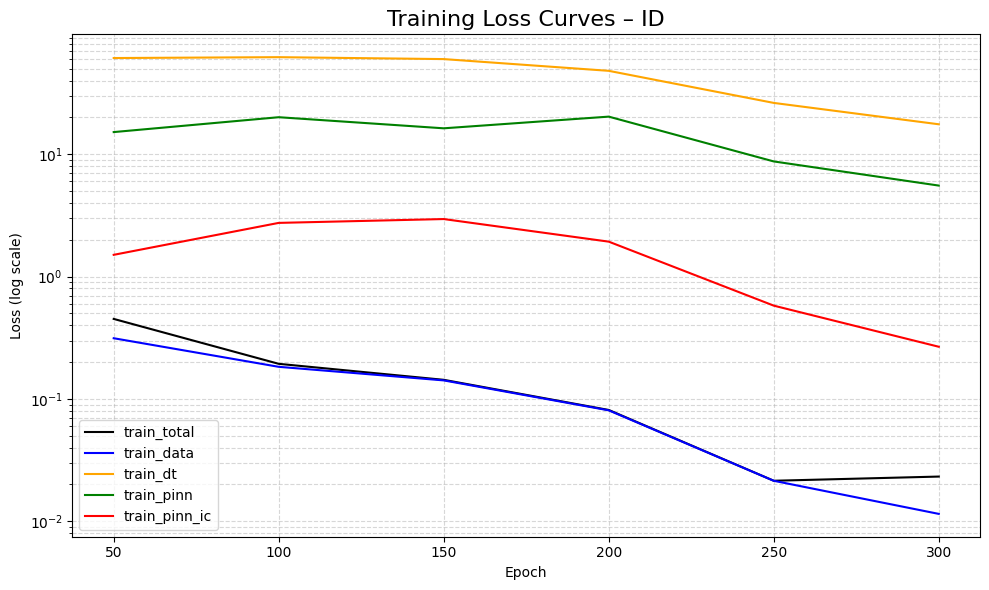

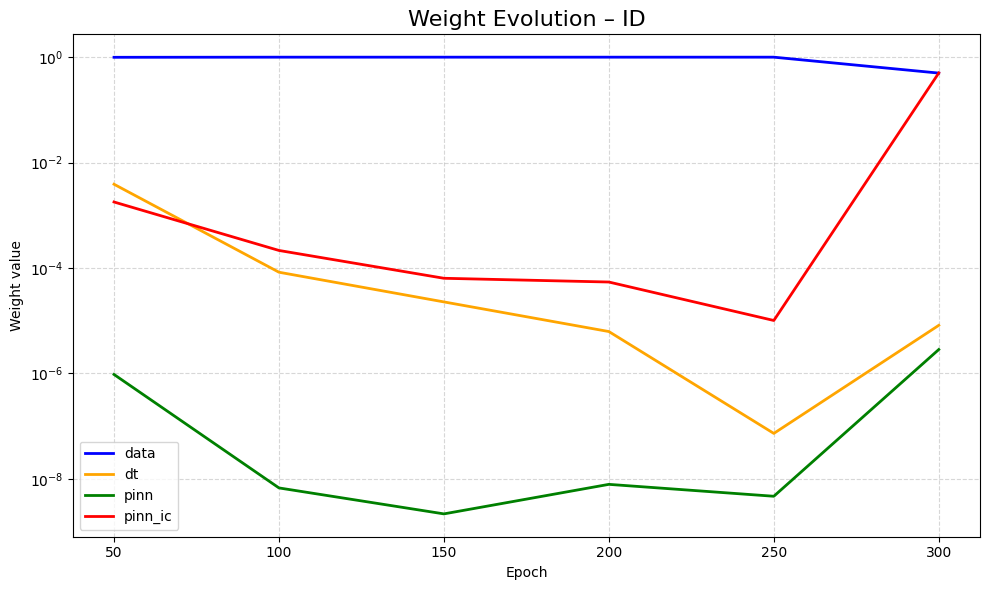

In [39]:
log = load_clean_log("ID")

show_log(log)

plot_losses(log, "ID")
plot_weights(log, "ID")

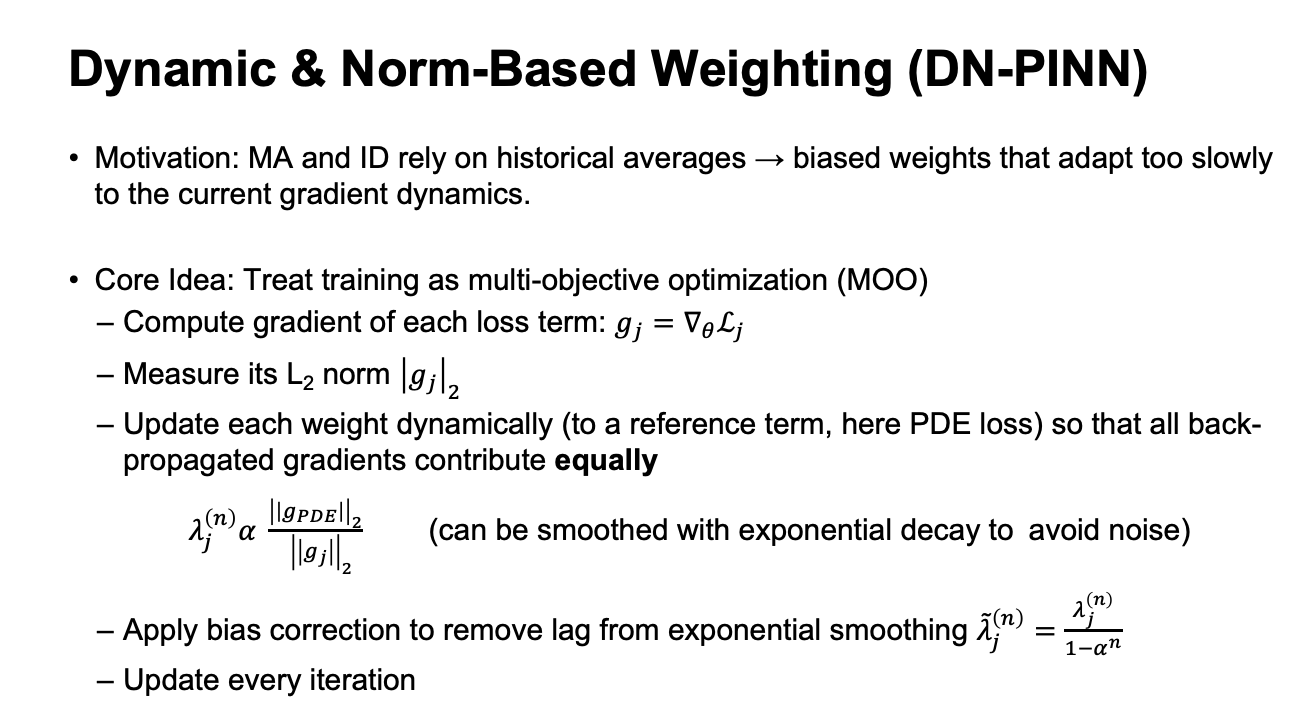

In [5]:
train_weighting_scheme(cfg, dataset_path, "DN", epochs=300)


TRAINING SCHEME: DN
SM_AVR_GOV data
Loading data from: data/SM_AVR_GOV/dataset_set5_mixed.pkl
Number of training samples:  80000 Number of validation samples:  10000 Number of testing samples:  10000
Number of different initial conditions for collocation points:  100
['theta', 'omega', 'E_d_dash', 'E_q_dash', 'R_F', 'V_r', 'E_fd', 'P_sv', 'P_m'] Variables
[[-2, 2], [-1, 1], [0], [1], [1], [1.105], [1.08], [0.7048], [0.7048]] Set of values for init conditions
[10, 10, 1, 1, 1, 1, 1, 1, 1] Iterations per value
Selected deep learning model:  DynamicNN
Number of labeled training data: 5600 Number of collocation points: 7000 Number of collocation points (IC): 100 Number of validation data: 10000
Weights initialized as:  [1, 0.001, 0.0001, 0.001]  are updated with scheme:  DN every 5 epochs
Logging training to model/data_dt_pinn_ic/training_log_DN.csv
getting in training
Updating weights at epoch 5

[Epoch 4] Updating weights (DN)
  ‖∇θ L_0‖ = 2.466e+00
  ‖∇θ L_1‖ = 1.084e+00
  ‖∇θ L_2‖ = 1

Using log: model/data_dt_pinn_ic/training_log_DN.csv

First rows of log:


,epoch,train_total,train_data,train_dt,train_pinn,train_pinn_ic,val_total,val_data,val_dt,weight_data,weight_dt,weight_pinn,weight_pinn_ic,elapsed_s
0,50,8.329673,1.107674,18.200741,39.262444,0.250283,18.901248,1.094621,17.806627,0.397005,0.425773,0.000669,0.176552,25.516293
1,100,1.194752,0.148612,3.332206,6.725811,0.171602,3.286149,0.145454,3.140695,0.492897,0.316768,0.001362,0.188973,51.045085
2,150,0.267701,0.055323,1.170575,1.283375,0.061354,0.939815,0.050431,0.889384,0.688609,0.152147,0.001817,0.157427,76.933490
3,200,0.058834,0.025808,0.608759,0.412402,0.019247,0.639845,0.023793,0.616052,0.847193,0.051455,0.001614,0.099738,104.031617
4,250,0.033574,0.019360,0.546603,0.276003,0.011073,0.576673,0.017301,0.559372,0.867330,0.026369,0.001694,0.104608,130.672593
5,300,0.024292,0.017252,0.515902,0.217550,0.008261,0.548377,0.015116,0.533262,0.881216,0.014401,0.001643,0.102740,155.874576


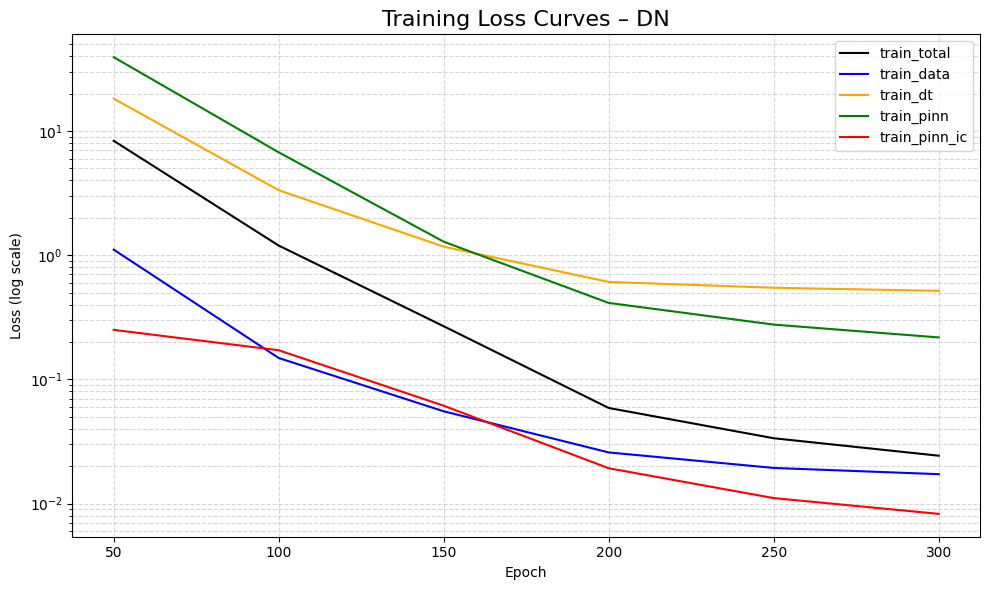

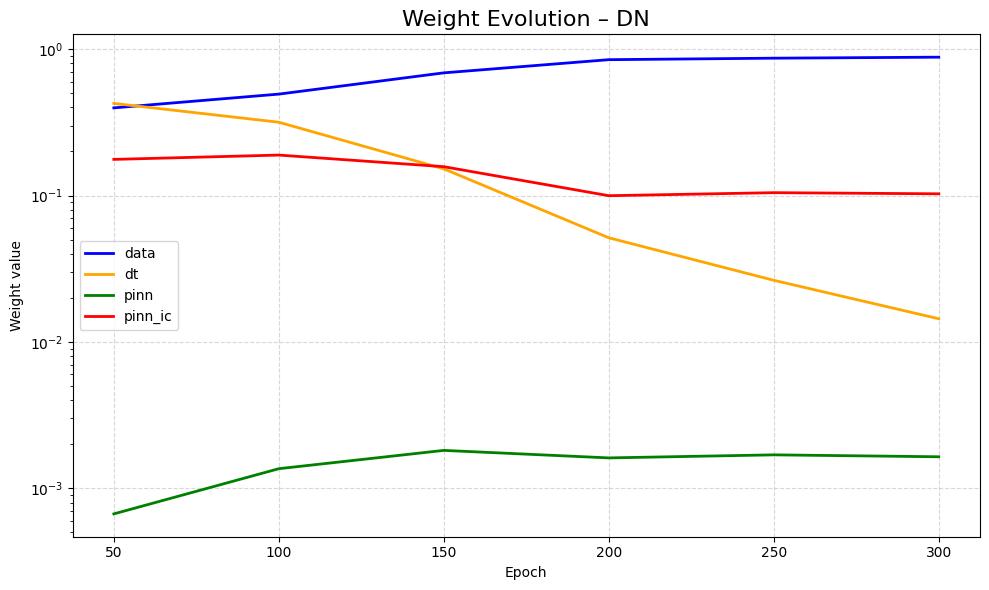

In [40]:
log = load_clean_log("DN")

show_log(log)

plot_losses(log, "DN")
plot_weights(log, "DN")

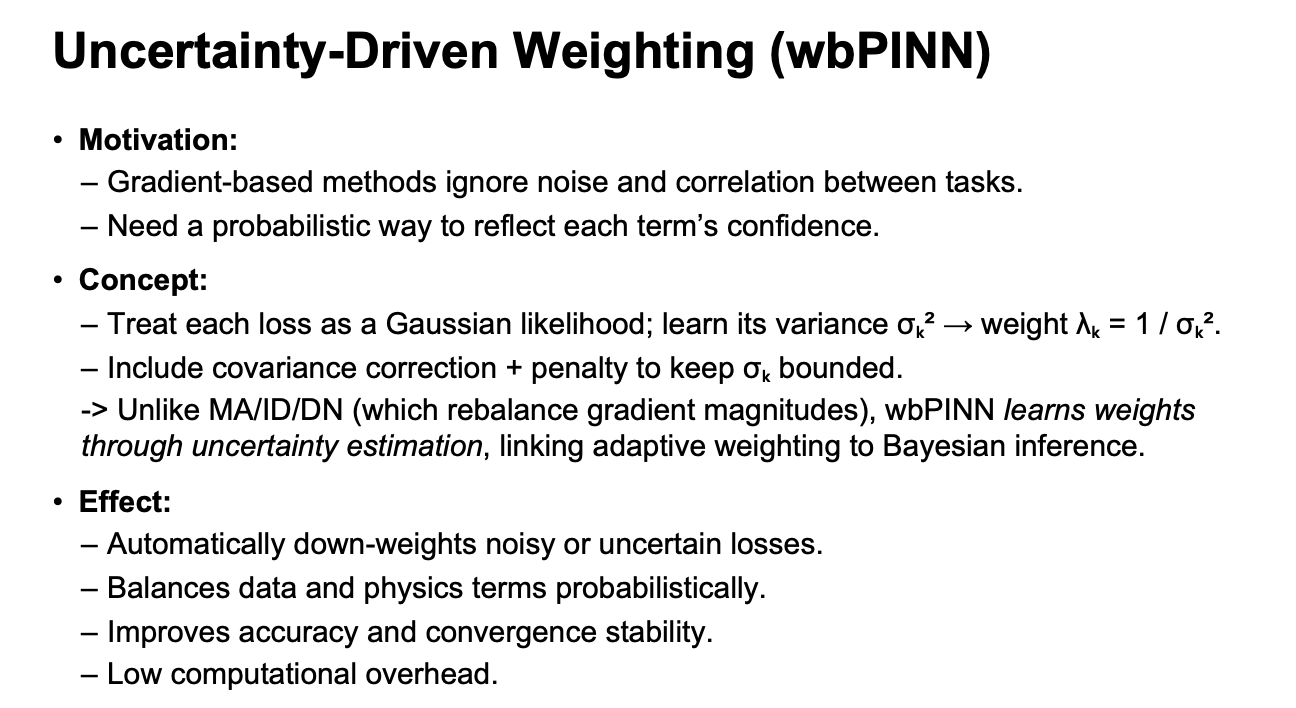

In [21]:
train_weighting_scheme(cfg, dataset_path, "WB", epochs=300)


TRAINING SCHEME: WB
SM_AVR_GOV data
Loading data from: data/SM_AVR_GOV/dataset_set5_mixed.pkl
Number of training samples:  80000 Number of validation samples:  10000 Number of testing samples:  10000
Number of different initial conditions for collocation points:  100
['theta', 'omega', 'E_d_dash', 'E_q_dash', 'R_F', 'V_r', 'E_fd', 'P_sv', 'P_m'] Variables
[[-2, 2], [-1, 1], [0], [1], [1], [1.105], [1.08], [0.7048], [0.7048]] Set of values for init conditions
[10, 10, 1, 1, 1, 1, 1, 1, 1] Iterations per value
Selected deep learning model:  DynamicNN
Number of labeled training data: 5600 Number of collocation points: 7000 Number of collocation points (IC): 100 Number of validation data: 10000
Weights initialized as:  [1, 0.001, 0.0001, 0.001]  are updated with scheme:  WB every 5 epochs
Logging training to model/data_dt_pinn_ic/training_log_WB.csv
getting in training
Updating weights at epoch 5

[Epoch 4] Updating weights (WB)
  → Updated weights: [0.0764, 0.9004, 0.0, 0.0232]
Epoch 5 –

Using log: model/data_dt_pinn_ic/training_log_WB.csv

First rows of log:


,epoch,train_total,train_data,train_dt,train_pinn,train_pinn_ic,val_total,val_data,val_dt,weight_data,weight_dt,weight_pinn,weight_pinn_ic,elapsed_s
0,50,0.347254,0.314486,61.438828,12.249285,1.562572,60.695577,0.312596,60.382980,0.999222,7.350406e-04,1.013936e-10,4.342805e-05,24.784293
1,100,0.201954,0.201216,62.470135,31.122297,2.473996,61.600466,0.196440,61.404026,0.999990,4.082061e-06,1.601372e-12,5.980270e-06,49.528804
2,150,0.152164,0.152162,61.725449,13.601803,3.174402,60.763731,0.150198,60.613533,1.000000,3.300453e-08,2.130396e-14,1.002129e-07,74.637882
3,200,0.120738,0.120727,57.642315,18.707628,2.768004,56.440775,0.117792,56.322983,0.999999,1.602817e-07,1.661142e-13,6.436321e-07,99.724808
4,250,0.053614,0.053613,40.690777,14.325191,1.415627,39.029295,0.050642,38.978653,1.000000,5.807139e-10,1.033436e-12,1.487940e-07,124.289180
5,300,0.012834,0.012834,21.241974,8.756969,0.351081,20.156411,0.012543,20.143867,1.000000,1.458417e-12,5.297297e-14,1.042870e-08,148.871200


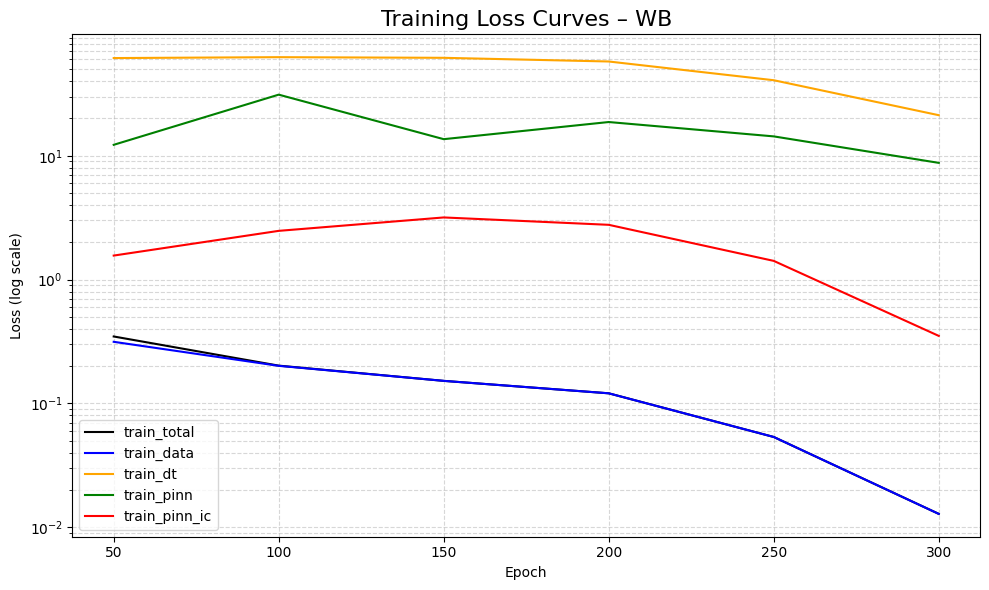

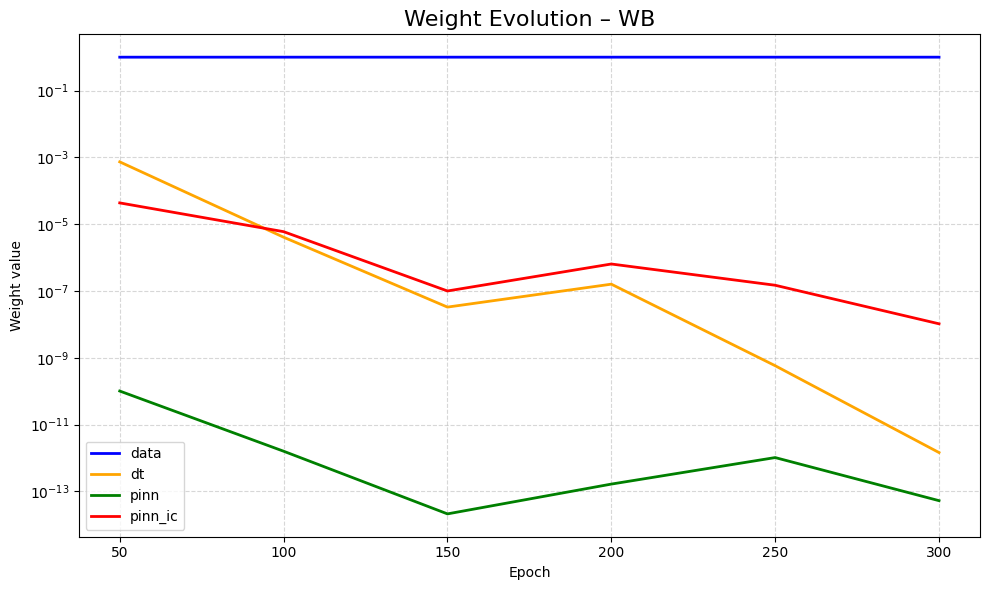

In [41]:
log = load_clean_log("WB")

show_log(log)

plot_losses(log, "WB")
plot_weights(log, "WB")

### SAM

In [4]:
train_weighting_scheme(cfg, dataset_path, "Sam", epochs=300)


TRAINING SCHEME: Sam
SM_AVR_GOV data
Loading data from: data/SM_AVR_GOV/dataset_set5_mixed.pkl


/zhome/14/b/214266/DTU_PINNs/src/nn/nn_dataset.py:189: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at ../torch/csrc/utils/tensor_new.cpp:261.)
  training_sample = torch.tensor(training_sample, dtype=torch.float32) # convert the trajectory to tensor


Number of training samples:  80000 Number of validation samples:  10000 Number of testing samples:  10000
Number of different initial conditions for collocation points:  100
['theta', 'omega', 'E_d_dash', 'E_q_dash', 'R_F', 'V_r', 'E_fd', 'P_sv', 'P_m'] Variables
[[-2, 2], [-1, 1], [0], [1], [1], [1.105], [1.08], [0.7048], [0.7048]] Set of values for init conditions
[10, 10, 1, 1, 1, 1, 1, 1, 1] Iterations per value
Selected deep learning model:  DynamicNN
Number of labeled training data: 5600 Number of collocation points: 7000 Number of collocation points (IC): 100 Number of validation data: 10000
Weights initialized as:  [1, 0.001, 0.0001, 0.001]  are updated with scheme:  Sam every 5 epochs
Logging training to model/data_dt_pinn_ic/training_log_Sam.csv
getting in training
0.1* sam tensor([9.7598e-03, 3.3583e-04, 7.2856e-05, 3.3339e-02])
Parameter containing:
tensor([1.0098e+00, 1.3358e-03, 1.7286e-04, 3.4339e-02], requires_grad=True)
0.1* sam tensor([0.0422, 0.0003, 0.0007, 0.0156])

Using log: model/data_dt_pinn_ic/training_log_Sam.csv

First rows of log:


,epoch,train_total,train_data,train_dt,train_pinn,train_pinn_ic,val_total,val_data,val_dt,weight_data,weight_dt,weight_pinn,weight_pinn_ic,elapsed_s
0,50,0.885204,0.287453,59.748848,0.320939,1.601511,62.971534,0.303199,62.668335,1.557693,0.004350,0.028002,0.143446,21.300875
1,100,2.497694,0.315808,59.723186,8.972786,1.489856,62.961922,0.323868,62.638054,2.234404,0.007698,0.112085,0.275450,42.316749
2,150,2.297834,0.301123,59.667866,0.903220,1.451002,62.905481,0.317468,62.588013,2.891546,0.011049,0.271582,0.414278,63.879430
3,200,3.117781,0.321508,59.643703,0.956647,1.344017,62.900856,0.338005,62.562851,3.525705,0.014401,0.481345,0.559956,85.093390
4,250,4.216436,0.327181,59.624313,1.092612,1.291864,62.882551,0.340140,62.542412,4.141685,0.017755,0.900134,0.710809,106.993324
5,300,61.370811,0.393702,59.576679,45.662930,1.479645,62.905769,0.408313,62.497456,4.732649,0.021111,1.249659,0.864927,128.124921


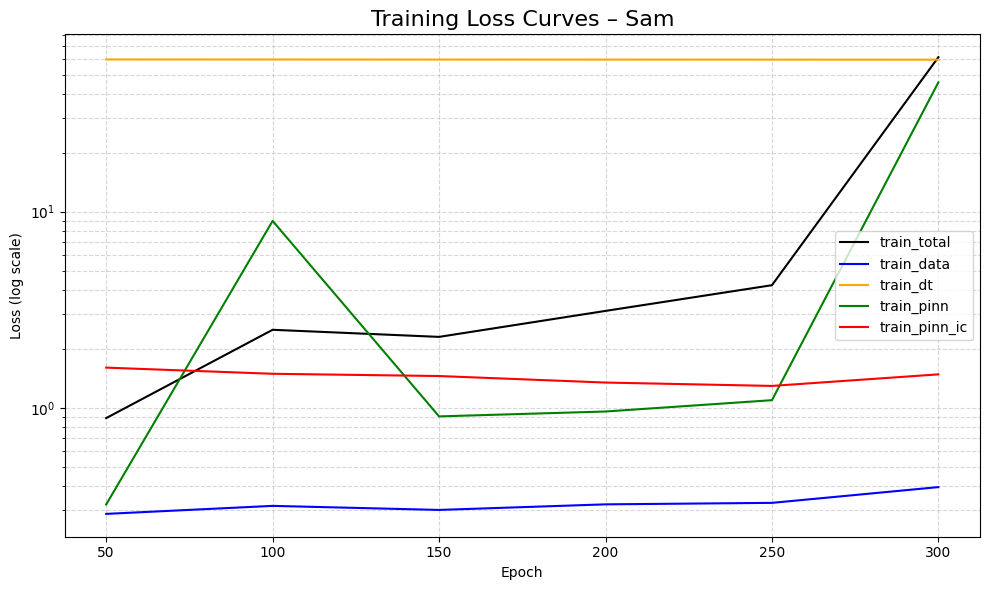

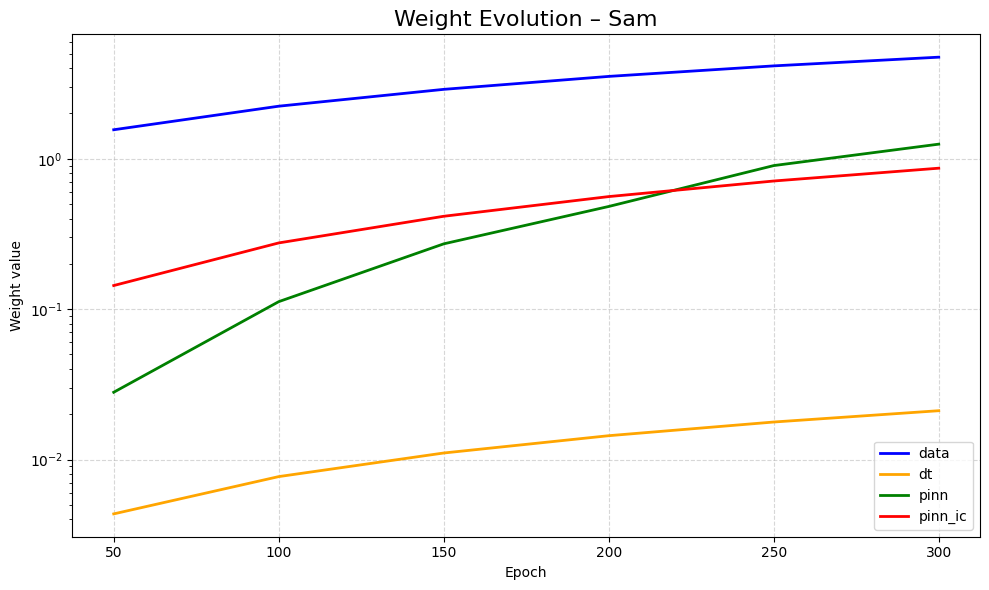

In [10]:
log = load_clean_log("Sam")

show_log(log)

plot_losses(log, "Sam")
plot_weights(log, "Sam")

### Comparison of final error

In [6]:
schemes = ["Static", "Gradient", 
           "DN", "ID", "WB",
           "Sam"
           ]

logs = {}
for scheme in schemes:
    path = f"model/data_dt_pinn_ic/training_log_{scheme}.csv"
    try:
        logs[scheme] = pd.read_csv(path)
        print(f"Loaded {scheme}: {logs[scheme].shape}")
    except:
        print(f"Could not load: {path}")

final_vals = {}
for scheme, df in logs.items():
    final_vals[scheme] = df["val_total"].iloc[-1]

Loaded Static: (6, 14)
Loaded Gradient: (32, 14)
Loaded DN: (6, 14)
Loaded ID: (6, 14)
Loaded WB: (6, 14)
Loaded Sam: (6, 14)


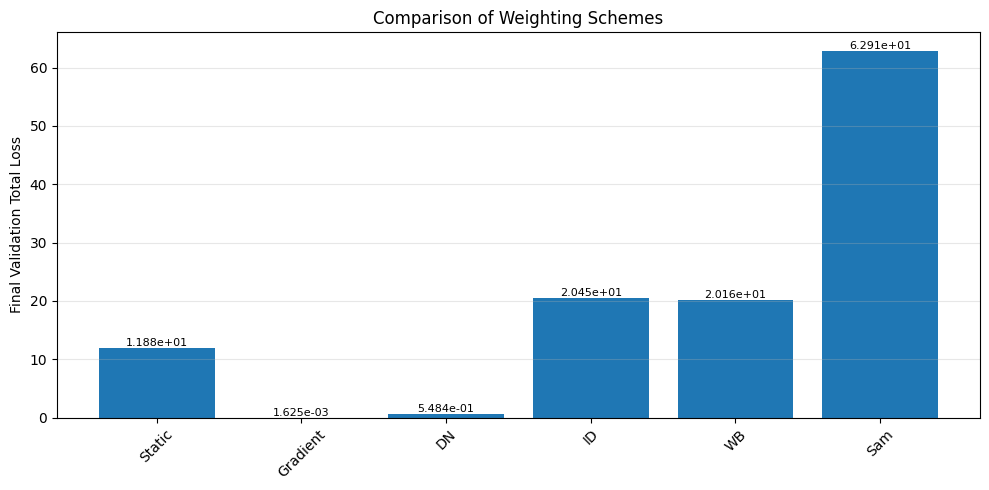

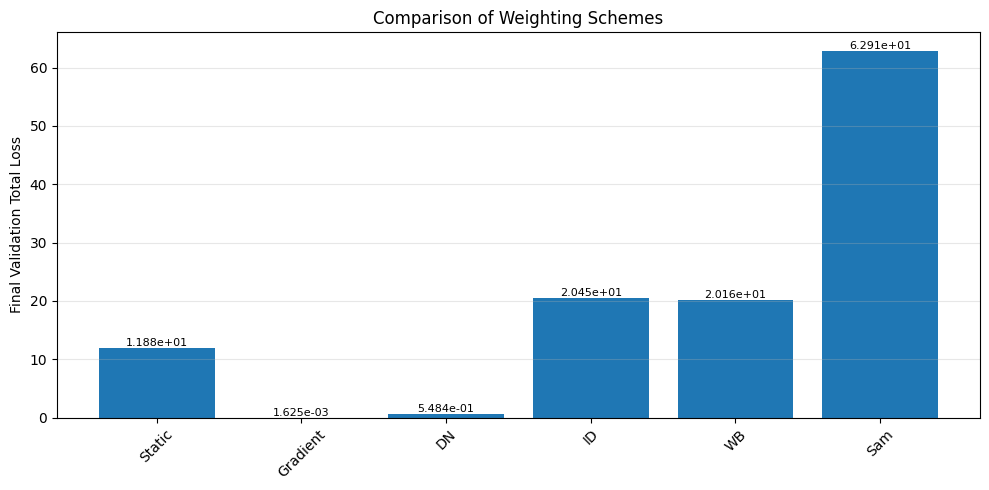

In [9]:
plt.figure(figsize=(10,5))

schemes_plot = list(final_vals.keys())
values = [final_vals[s] for s in schemes_plot]

bars = plt.bar(schemes_plot, values)

plt.ylabel("Final Validation Total Loss")
plt.title("Comparison of Weighting Schemes")
plt.xticks(rotation=45)

# Annotate bars with values
for bar, val in zip(bars, values):
    y = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, y,
             f"{val:.3e}",
             ha='center', va='bottom', fontsize=8)

plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()